**Outliers:**

An outlier is an observation that is unusually far from the other observations in a dataset or does not follow the general pattern.

Simple example

Consider these monthly salaries:

25000, 27000, 26000, 28000, 30000, 250000

Most salaries are between 25,000 and 30,000. The value 250000 is much higher than the others and may be an outlier.

An outlier is not automatically a mistake. It could represent:

A data entry error

A measurement error

A rare but genuine event

A naturally unusual observation

**Business and AI/ML example:**

Business: An unusually large transaction could be a genuine bulk purchase or a potentially fraudulent transaction.

AI/ML: Extreme values can influence the training of some models, particularly methods that depend on means, variances, or squared errors.

In [1]:
import pandas as pd

salaries = pd.Series([
    25000, 27000, 26000, 28000, 30000, 250000
])

print("Mean:", salaries.mean())
print("Median:", salaries.median())

Mean: 64333.333333333336
Median: 27500.0


**Types of Outliers:**

Outliers can be grouped into three common types.

1. Point (global) outlier:

A single observation that is unusually different from the rest of the dataset.

Example: A salary of ₹250,000 when most salaries are around ₹25,000–₹30,000.

2. Contextual outlier:

An observation that is unusual in a particular context, such as time, location, or season.

Example: Very high electricity usage during a mild-weather period may be unusual, even if that usage is normal during extreme summer heat.

3. Collective outlier:

A group or sequence of observations that is unusual when considered together, even if individual observations do not look extreme.

Example: A sudden sequence of unusual network traffic patterns may indicate an anomaly.


**AI/ML examples:**

Point outlier: One transaction has an unusually high amount.

Contextual outlier: A high temperature reading is unusual for the season and location.

Collective outlier: A sequence of login attempts has an unusual pattern.

These distinctions are useful because a method that detects unusually large individual values may miss contextual or collective anomalies

In [3]:
import pandas as pd

data = pd.DataFrame({
    "Day": [1, 2, 3, 4, 5, 6],
    "Temperature": [30, 31, 30, 32, 31, 45]
})

print(data)

   Day  Temperature
0    1           30
1    2           31
2    3           30
3    4           32
4    5           31
5    6           45


**Detecting Outliers:**

Outlier detection is the process of identifying observations that differ substantially from the expected data pattern.

Common techniques include:

Visual inspection using box plots and scatter plots

IQR method

Z-score method

Domain-specific thresholds

More advanced methods such as Isolation Forest and Local Outlier Factor

Different techniques can identify different observations. The suitable method depends on the data distribution, number of features, and purpose of the analysis.

**Business and AI/ML example:**

A data analyst investigating transaction amounts might:

Plot the distribution.

Apply the IQR method to flag unusually large or small amounts.

Check whether flagged records are valid purchases, errors, or possible fraud.

Decide how to handle them based on the analysis goal.

count       8.000000
mean      730.000000
std      1725.384015
min       100.000000
25%       113.750000
50%       122.500000
75%       132.500000
max      5000.000000
Name: Transaction_Amount, dtype: float64


<Axes: >

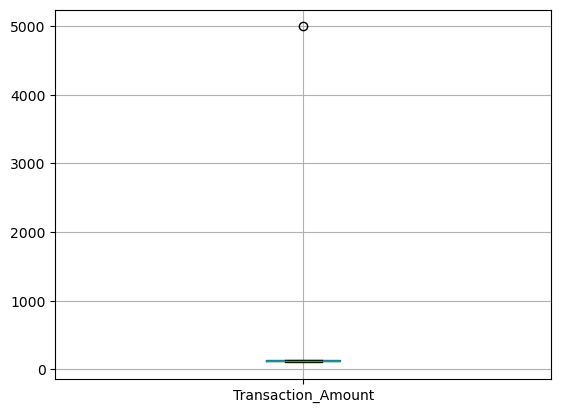

In [4]:
import pandas as pd

data = pd.DataFrame({
    "Transaction_Amount": [
        100, 120, 110, 130, 125, 115, 140, 5000
    ]
})

# Basic descriptive statistics
print(data["Transaction_Amount"].describe())

# Visual inspection
data.boxplot(column="Transaction_Amount")

**IQR Method:**

The Interquartile Range (IQR) measures the spread of the middle 50% of the data.

   IQR=Q3−Q1

Where:
 Q1= 25th percentile
 Q2= 75th percentile
The common 1.5 × IQR rule flags observations outside these fences:

       Lower bound=Q1−1.5(IQR)
       Upper bound=Q3+1.5(IQR)

In [8]:
import pandas as pd

data = pd.Series([10, 12, 13, 14, 15, 18, 20, 100])

Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = data[(data < lower_bound) | (data > upper_bound)]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Potential outliers:", outliers.tolist())

Q1: 12.75
Q3: 18.5
IQR: 5.75
Lower bound: 4.125
Upper bound: 27.125
Potential outliers: [100]


**Z-Score Method:**

A Z-score describes how many standard deviations an observation is above or below the mean.

In [9]:
import pandas as pd
from scipy.stats import zscore

data = pd.Series([25, 27, 26, 28, 30, 29, 31, 100])

# Calculate population-standardized Z-scores
z_scores = zscore(data, ddof=0)

result = pd.DataFrame({
    "Value": data,
    "Z_Score": z_scores
})

# Common heuristic threshold
outliers = result[result["Z_Score"].abs() > 3]

print(result.round(2))
print("\nPotential outliers:")
print(outliers)

   Value  Z_Score
0     25    -0.50
1     27    -0.42
2     26    -0.46
3     28    -0.38
4     30    -0.29
5     29    -0.33
6     31    -0.25
7    100     2.64

Potential outliers:
Empty DataFrame
Columns: [Value, Z_Score]
Index: []


**Box Plot:**

A box plot (or box-and-whisker plot) summarizes a numerical distribution using:

  Lower quartile Q1,
  Median Q2,
  Upper quartile Q3 ,
  Interquartile range IQR

Whiskers extending to values within the plot's chosen limits

Individual points beyond the whiskers, often shown as potential outliers

In a standard Tukey box plot, the whiskers typically extend to the most extreme observed values still within the 1.5 × IQR fences. The whiskers are not necessarily the minimum and maximum values.

**Business and AI/ML example:**

Business: Compare delivery times across different regions and identify unusually long deliveries.

AI/ML: Use box plots during exploratory data analysis to inspect feature distributions and potential extreme values.

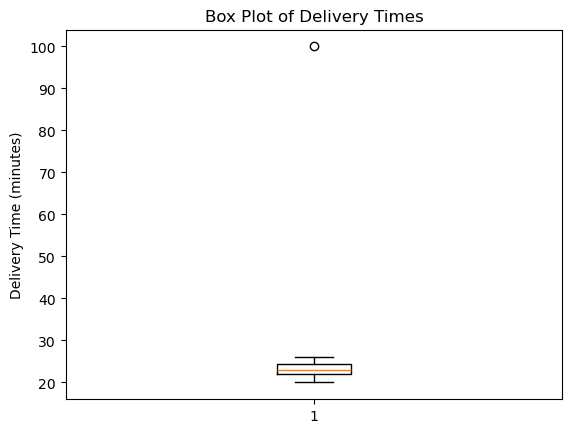

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.Series([
    20, 22, 21, 23, 24, 22, 25, 26, 24, 23, 100
])

plt.boxplot(data)
plt.ylabel("Delivery Time (minutes)")
plt.title("Box Plot of Delivery Times")
plt.show()

**Scatter Plot:**

A scatter plot displays the relationship between two numerical variables by plotting each observation as a point.

It can help identify:

Unusual individual observations

Clusters or groups

Linear or nonlinear relationships

Changes in spread

Possible contextual or multivariate anomalies

A point that looks unusual in a scatter plot may not be an outlier in either variable separately. It may be unusual because of the combination of its two values.

**Business and AI/ML example:**

Business: Plot advertising expenditure against sales to identify observations that do not follow the general relationship.

AI/ML: Plot actual versus predicted values to investigate observations with unusually large prediction errors.

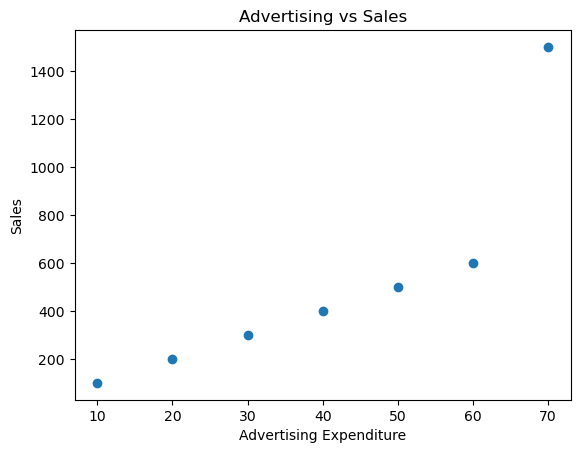

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.DataFrame({
    "Advertising": [10, 20, 30, 40, 50, 60, 70],
    "Sales": [100, 200, 300, 400, 500, 600, 1500]
})

plt.scatter(data["Advertising"], data["Sales"])
plt.xlabel("Advertising Expenditure")
plt.ylabel("Sales")
plt.title("Advertising vs Sales")
plt.show()